In [13]:
import numpy as np

from data_loader import DataLoader
from pathlib import Path

data_file = Path("~/.propdata/data.pkl").expanduser().resolve()
data = DataLoader(data_file).load()

Found C:\Users\ysuho\.propdata\data.pkl with data. Skipping download.


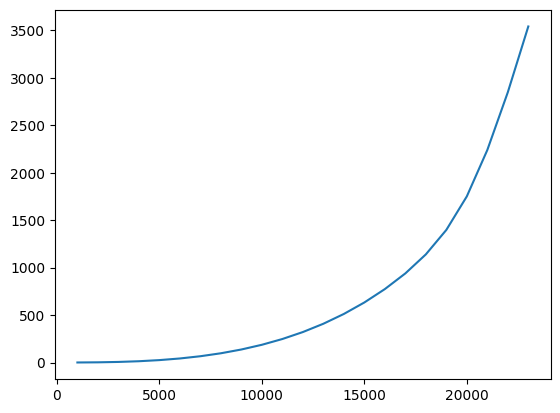

In [14]:
from models import Columns
import matplotlib.pyplot as plt
exemplar = data[0]
plt.plot(exemplar.rpms, exemplar.matrices[Columns.POWER][:, 0])
plt.show()

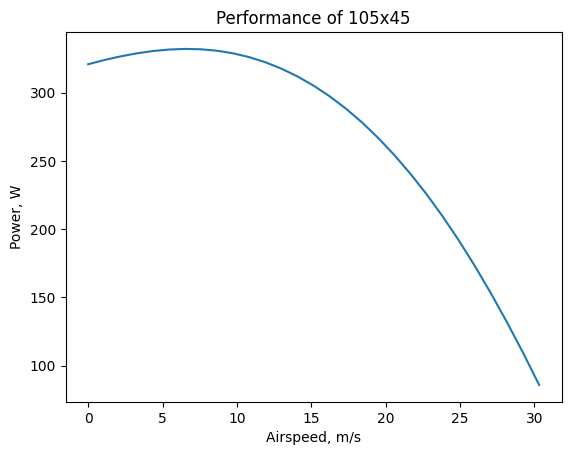

In [15]:
plt.plot(exemplar.matrices[Columns.AIRSPEED][len(exemplar.rpms)//2], exemplar.matrices[Columns.POWER][len(exemplar.rpms)//2],)
plt.xlabel("Airspeed, m/s")
plt.ylabel("Power, W")
plt.title(f"Performance of {data[0].name}")
plt.show()

Here we assume the energy of the battery as 98Wh as advertised

They start with a battery that's about 90% full (from 80 to 95%), and then 10 minutes of climbout will consume some more energy and the voltage will drop.

We approximate the climbout with the values for static thrust, hoping that we land somewhere in the "slower than 10ms" region where we can approximate the power at an airspeed simply by the static thrust power

And we consider the voltage to be constant

In [16]:
batt_full = 98
batt_start = 0.9*batt_full

cell_count = 6
voltage_start = 4.0627906977
current_full_throttle = 17.6981132075
#current_cruise_throttle = 4.1538461538  # Raven B DDL
current_cruise_throttle = 1.45 # Raven B

And with this graph
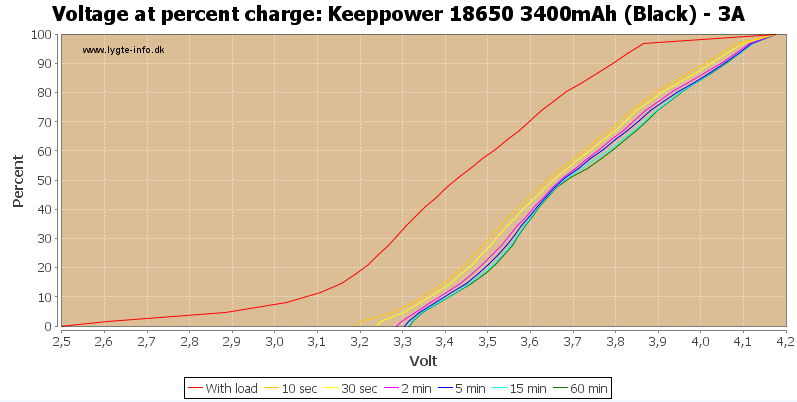

We will need the efficiency of ESC and Motor, since we don't have any official data, let's approximate it with a high-end motor that has a similar power output and revv and a matching ESC

https://database.tytorobotics.com/tests/d6k3/t-motor-at2814-kv900-graupner-10x5

No information about the propeller is available, and the efficiency varies wildly with the prop size, we use the efficiency of 80% (ESC + Motor)



In [17]:

import math

efficiency = 0.8
power_draw_static = cell_count * voltage_start * current_cruise_throttle
power_mechanical = power_draw_static * efficiency
power_mechanical

28.277023255992

With this image a prop diameter is approximated to be about 8.5 inches
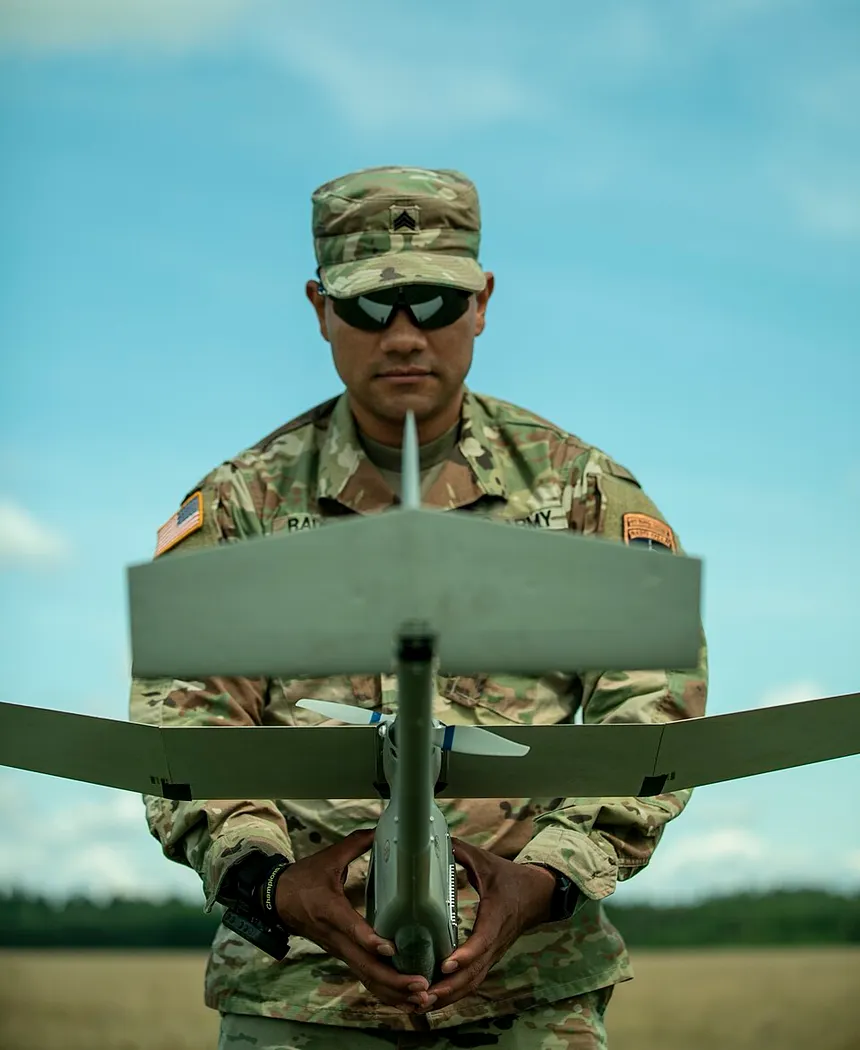

In [18]:
from config import ConstraintPoint, ConstraintEntry, ConditionEntry, ConstraintConfig
from optimisator import optimize

cc = ConstraintConfig(
    constraints=[
        ConstraintPoint(
            name = "global",
            entries = [
                ConstraintEntry(
                    name="dia",
                    low = 8,
                    high = 9,
                )
            ]
        )
    ],
    conditions = [
        ConditionEntry(
            name = "static",
            airspeed=0,
            input=Columns.POWER,
            input_value=power_mechanical
        )]
)

result = optimize(cc, data)

100%|██████████| 448/448 [00:15<00:00, 28.85it/s]


The cruise speed is stated as 13.37 m/s

In [19]:
from typing import Literal
from tqdm import tqdm
from models import Prop
from interpolator import PropInterpolator

cruise_speed = 13.37

prop_analyses: list[tuple[Prop,  dict[Columns | Literal["rpm"], float]]] = []

for entry in tqdm(result):
    prop, analysis_data = entry[0]

    rpm = analysis_data['rpm']
    prop_name = prop.name

    interp = PropInterpolator(prop)
    prop_analysis_at_cruise = interp.evaluate_point(
        ConditionEntry(
            name=prop.name,
            airspeed=cruise_speed,
            input='rpm',
            input_value=rpm
        )
    )
    if not prop_analysis_at_cruise:
        continue
    prop_analyses.append((prop, prop_analysis_at_cruise))

  4%|▍         | 3/77 [00:00<00:02, 26.34it/s]

Target rpm 5743.930006246643 is outside the achievable range at airspeed 13.37


 39%|███▉      | 30/77 [00:01<00:01, 25.31it/s]

Target rpm 8993.628286860532 is outside the achievable range at airspeed 13.37
Target rpm 6423.712614096275 is outside the achievable range at airspeed 13.37


 47%|████▋     | 36/77 [00:01<00:01, 25.41it/s]

...

Target rpm 5100.724753257589 is outside the achievable range at airspeed 13.37
Target rpm 5709.350817700956 is outside the achievable range at airspeed 13.37
Target rpm 4483.389094429039 is outside the achievable range at airspeed 13.37


 91%|█████████ | 70/77 [00:02<00:00, 28.00it/s]

Target rpm 4698.854605224906 is outside the achievable range at airspeed 13.37


100%|██████████| 77/77 [00:02<00:00, 26.08it/s]

Target rpm 649.9170454397027 is outside the achievable range at airspeed 13.37
Target rpm 616.7410177301374 is outside the achievable range at airspeed 13.37


In [20]:
res = sorted([x for x in prop_analyses if x[1]], key = lambda x: x[1][Columns.PROP_EFF])
res = [x for x in res if x[1][Columns.PROP_EFF] > 0.6]
prop_analyses_filtered = [(x[0].name, x[1][Columns.THRUST], x[1][Columns.POWER], x[1][Columns.PROP_EFF]) for x in res]
prop_analyses_filtered

[('9x6e', 0.76024866689023, 16.10445587056007, 0.6221712852434319),
 ('9x6', 0.9321518980562034, 19.359997616480577, 0.6360461674530201),
 ('8x5', 1.029266561842499, 21.376611844898683, 0.6421884282752576),
 ('9x65', 1.0880452188940102, 21.427189198041816, 0.6752858713528831),
 ('9x6n', 1.478753709583536, 29.02257099828536, 0.6829896774354934),
 ('8x10', 2.0441383787578293, 39.48789245424537, 0.6895695874314787),
 ('8x6', 1.3682085790534768, 26.582224895671587, 0.6903062574797953),
 ('8x9', 2.0100258086462435, 38.50400798982667, 0.6985294593182313),
 ('8x73', 1.907766664230556, 36.45845936630938, 0.698606204356813),
 ('88x89', 1.9236926426640502, 36.86210440573357, 0.6990813717680723),
 ('9x7', 1.2252184655879714, 23.630592661565252, 0.7015046051875039),
 ('8x7', 1.6252030219189122, 31.000095187239985, 0.7017400076049173),
 ('8x8', 1.856030360833855, 35.34872830429364, 0.7017822646852067),
 ('875x75w', 1.754262364665141, 33.304039203993696, 0.7047529266808372),
 ('875x925nn', 2.0921829

In [21]:

import numpy as np
print("Min thrust")
propeller, propeller_data = min(res, key=lambda x: x[1][Columns.THRUST])
print(propeller.name, propeller_data)
propeller, propeller_data = max(res, key=lambda x: x[1][Columns.THRUST])
print(propeller.name, propeller_data)

print("Avg thrust")
print(np.mean([x[1][Columns.THRUST] for x in res]))

Min thrust
9x6e {<Columns.AIRSPEED: 0>: 13.369999999999997, <Columns.ADV_RATIO: 1>: 0.6775782480445672, <Columns.PROP_EFF: 2>: 0.6221712852434319, <Columns.THRUST_COEFF: 3>: 0.030386623994867867, <Columns.POWER_COEFF: 4>: 0.032651649452358045, <Columns.POWER: 8>: 16.10445587056007, <Columns.TORQUE: 9>: 0.02961213851301602, <Columns.THRUST: 10>: 0.76024866689023, <Columns.THRUST_TO_PWR: 11>: 4.74443211368243, <Columns.MACH: 12>: 0.18957878028627168, <Columns.RE: 13>: 57970.28560781367, <Columns.FOM: 14>: 0.12896563001266123, 'rpm': 5181.773854351488}
875x925nn {<Columns.AIRSPEED: 0>: 13.370000000000001, <Columns.ADV_RATIO: 1>: 0.6277249265779365, <Columns.PROP_EFF: 2>: 0.7057304580100915, <Columns.THRUST_COEFF: 3>: 0.07617245232588732, <Columns.POWER_COEFF: 4>: 0.06786808077850806, <Columns.POWER: 8>: 39.679812001717494, <Columns.TORQUE: 9>: 0.06560929130273434, <Columns.THRUST: 10>: 2.0921829278375568, <Columns.THRUST_TO_PWR: 11>: 5.38257041011131, <Columns.MACH: 12>: 0.201635788660716

In [22]:
power_mechanical = 27.27 * 0.8
#power_mechanical = 4.1 * voltage_start * 6 * 0.8

cc = ConstraintConfig(
    constraints=[
        ConstraintPoint(
            name = "global",
            entries = [
                ConstraintEntry(
                    name="dia",
                    low = 8,
                    high = 9,
                )
            ]
        )
    ],
    conditions = [
        ConditionEntry(
            name = "static",
            airspeed=cruise_speed,
            input=Columns.POWER,
            input_value=power_mechanical
        )]
)

result = optimize(cc, data)

100%|██████████| 448/448 [00:14<00:00, 30.79it/s]


In [23]:
from models import Prop

constraints = cc
results = result
def weight_efficiencies(prop_results: list[tuple[Prop, dict[Columns | str, float]]]) -> float:
    return sum([
        prop_result[1][Columns.PROP_EFF] * cond.weight
        for prop_result, cond in zip(prop_results, constraints.conditions)
    ])
# Calculate weighted efficiencies
results_sorted = sorted(results, key=weight_efficiencies, reverse=True)
print(f"\n\nEvaluated {len(data)} props, {len(results_sorted)} matches, 5 best power efficiencies")
print(f"Conditions: {' '.join([str(cond) for cond in constraints.conditions])}")
for experiment in results_sorted[:5]:
    print(f"Prop: {experiment[0][0].name}, \n\t"
          f"dimensions: {experiment[0][0].dia}x{experiment[0][0].pitch}, \n\t"
          f"efficiency: {' '.join(['{:.4f}'.format(res[1][Columns.PROP_EFF]) for res in experiment])} \n\t"
          f"RPM: {' '.join(['{:.4f}'.format(res[1]['rpm']) for res in experiment])} \n\t"
          f"torque: {' '.join(['{:.4f}'.format(res[1][Columns.TORQUE]) for res in experiment])} \n\t"
          f"power: {' '.join(['{:.4f}'.format(res[1][Columns.POWER]) for res in experiment])}\n\t"
          f"thrust: {' '.join(['{:.4f}'.format(res[1][Columns.THRUST]) for res in experiment])}")



Evaluated 448 props, 70 matches, 5 best power efficiencies
Conditions: ConditionEntry(name='static', airspeed=13.37, thrust=None, weight=1.0, input=<Columns.POWER: 8>, input_value=21.816000000000003)
Prop: 8x10, 
	dimensions: 8.0x10.0, 
	efficiency: 0.7563 
	RPM: 4628.7027 
	torque: 0.0458 
	power: 21.8160
	thrust: 1.1953
Prop: 9x10, 
	dimensions: 9.0x10.0, 
	efficiency: 0.7559 
	RPM: 4150.3452 
	torque: 0.0501 
	power: 21.8160
	thrust: 1.2120
Prop: 9x9e, 
	dimensions: 9.0x9.0, 
	efficiency: 0.7543 
	RPM: 4250.5185 
	torque: 0.0487 
	power: 21.8160
	thrust: 1.2360
Prop: 8x8e, 
	dimensions: 8.0x8.0, 
	efficiency: 0.7508 
	RPM: 5028.1062 
	torque: 0.0415 
	power: 21.8160
	thrust: 1.2240
Prop: 8x73, 
	dimensions: 8.0x7.3, 
	efficiency: 0.7321 
	RPM: 5442.8877 
	torque: 0.0387 
	power: 21.8160
	thrust: 1.1776


In [24]:
thrusts_first_method = [x[0][1] for x in results_sorted]
print("Min thrust")
print(min(thrusts_first_method, key=lambda x: x[Columns.THRUST]))
print("Max thrust")
print(max(thrusts_first_method, key=lambda x: x[Columns.THRUST]))

print("Avg thrust")
print(np.mean([x[Columns.THRUST] for x in thrusts_first_method]))

Min thrust
{<Columns.AIRSPEED: 0>: 13.369999999999997, <Columns.ADV_RATIO: 1>: 0.3824969793080962, <Columns.PROP_EFF: 2>: 0.36689408884403996, <Columns.THRUST_COEFF: 3>: 0.007725030959455087, <Columns.POWER_COEFF: 4>: 0.007940845354634884, <Columns.POWER: 8>: 21.816, <Columns.TORQUE: 9>: 0.022170849654495783, <Columns.THRUST: 10>: 0.6095457850280641, <Columns.THRUST_TO_PWR: 11>: 2.798172715884945, <Columns.MACH: 12>: 0.32830286397156927, <Columns.RE: 13>: 89730.56881979815, <Columns.FOM: 14>: 0.06832540202483679, 'rpm': 9178.178933453139}
Max thrust
{<Columns.AIRSPEED: 0>: 13.37, <Columns.ADV_RATIO: 1>: 0.8285580623997314, <Columns.PROP_EFF: 2>: 0.75426138522646, <Columns.THRUST_COEFF: 3>: 0.0722137353653467, <Columns.POWER_COEFF: 4>: 0.07841047971999356, <Columns.POWER: 8>: 21.816, <Columns.TORQUE: 9>: 0.04868501236951549, <Columns.THRUST: 10>: 1.2360236672303844, <Columns.THRUST_TO_PWR: 11>: 5.752799286682725, <Columns.MACH: 12>: 0.1562108743814783, <Columns.RE: 13>: 48213.9222875986

Now, T=D and W=L, and hence L/D = W/T, so the weight is 18.6N,  thrust for our second setup is 4.14, and the L/D is 4.49. So yeah, it's a brick.

As for the second method, thrusts are all over the place, so I don't know what to do with them



Text(0, 0.5, 'Drag coefficient CD0')

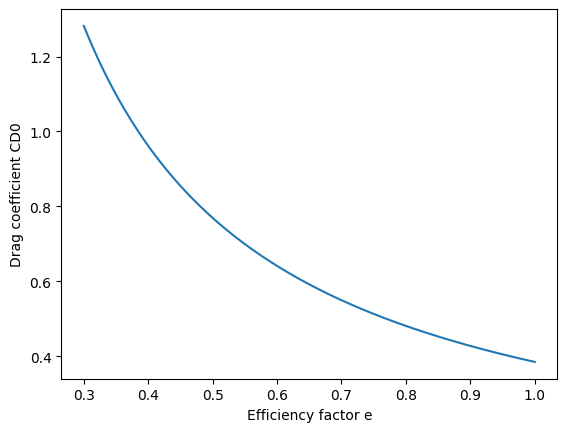

In [40]:
W = 18.5
s_wet = 0.262 * (W/9.82) ** 0.745
s_ref = 0.236
c_eff = 0.01115

CD_0 = c_eff * s_wet / s_ref

c_l_2 = (2 * W / (1.224 * cruise_speed**2 * s_ref))**2
wingspan = 1.298
AR = wingspan**2 / s_ref

e = c_l_2 / (3 * CD_0 * math.pi * AR)

cd_0_to_e = c_l_2 / (3 * CD_0 * math.pi * AR)

es = np.linspace(0.3, 1, 200)

plt.plot(es, cd_0_to_e/es)
plt.xlabel("Efficiency factor e")
plt.ylabel("Drag coefficient CD0")